<a href="https://colab.research.google.com/github/harjussingh/TIRP-Team02/blob/main/Symptom_Severness_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML Disease Classifier Pipeline (Clean Order)

This notebook is organized in one end-to-end flow:

1. Environment + dataset loading  
2. Preprocessing and data quality checks  
3. ATS disease labeling and curated filtering  
4. Feature matrix + train/test split  
5. Baseline model training (RF, DT, NB, ET)  
6. Evaluation and comparison  
7. Weighted ensemble  
8. TFLite export for Android/Windows  
9. Colab TFLite two-step scenario tests


## 1) Environment Setup


In [ ]:
import numpy as np
import pandas as pd

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2) Load Dataset


In [ ]:
INPUT_CSV = "/content/drive/MyDrive/Dataset/disease_dataset.csv"
df = pd.read_csv(INPUT_CSV)

## 2.1 Preprocessing and Data Cleaning


In [ ]:
DISEASE_COL = 'disease'

df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

# Older exports used "diseases"; disease_dataset.csv uses "disease"
if DISEASE_COL not in df.columns and 'diseases' in df.columns:
    df = df.rename(columns={'diseases': DISEASE_COL})

if DISEASE_COL not in df.columns:
    raise ValueError(f"Column '{DISEASE_COL}' not found in CSV")

# Clean text columns
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.strip().str.lower()

df = df.dropna()
df = df.drop_duplicates()

## 2.2 Class Frequency Filter


In [ ]:
min_samples = 50
df = df[df[DISEASE_COL].map(df[DISEASE_COL].value_counts()) >= min_samples]


In [ ]:
disease_counts = df[DISEASE_COL].value_counts().reset_index()
disease_counts.columns = ['disease_name', 'row_count']


In [ ]:
unique_diseases = df[DISEASE_COL].unique()
print("Total unique diseases:", len(unique_diseases))
print(unique_diseases)


Total unique diseases: 75
['pleuritis' 'kidney stone' 'tension headache' 'status epilepticus'
 'high altitude pulmonary oedema' 'moderate asthma attack'
 'acute heart failure' 'perforated appendicitis'
 'transient ischaemic attack' 'acute myocardial infarction'
 'massive stroke' 'severe pancreatitis' 'insomnia' 'acute pyelonephritis'
 'small pulmonary embolism' 'mild hypoglycaemia' 'constipation'
 'opioid overdose' 'diverticulitis' 'septic shock' 'mild dka'
 'cardiac arrest' 'ruptured aortic aneurysm' 'deep vein thrombosis'
 'haemorrhoids' 'tension pneumothorax' 'acute respiratory failure'
 'severe asthma attack' 'ankle sprain' 'acute urinary retention'
 'aortic dissection' 'bacterial meningitis' 'mild sunburn'
 'gastroenteritis' 'acute limb ischaemia' 'acute sinusitis'
 'severe sepsis' 'warts' 'tendinitis' 'anaphylactic shock' 'mild sprain'
 'massive pulmonary embolism' 'mouth ulcer' 'moderate allergic reaction'
 'sciatica' 'dry eye syndrome' 'common cold' 'moderate head injury'
 'bac

## 3) ATS Labeling Dictionary
Each entry maps an exact CSV disease name to ATS urgency level.

**ATS Levels**
- `1` = Resuscitation (Immediate)
- `2` = Emergency (<=10 min)
- `3` = Urgent (<=30 min)
- `4` = Semi-Urgent (<=60 min)
- `5` = Non-Urgent (<=120 min)


In [ ]:
# Curated ATS mapping used to label and filter diseases
# Format: "disease name as in CSV" : ats_level (1=most urgent, 5=least)
# NOTE: disease names MUST match the cleaned CSV values (lowercase after preprocessing)

SELECTED_DISEASES = {
    # ATS 1 (Emergency)
    "heart attack": 1,
    "cardiac arrest": 1,
    "stroke": 1,
    "ruptured aortic aneurysm": 1,
    "tension pneumothorax": 1,
    "anaphylactic shock": 1,
    "septic shock": 1,

    # ATS 2
    "aortic dissection": 2,
    "massive stroke": 2,
    "massive pulmonary embolism": 2,
    "acute respiratory failure": 2,
    "eclampsia": 2,
    "ectopic pregnancy rupture": 2,

    # ATS 3
    "acute myocardial infarction": 3,
    "unstable angina": 3,
    "small pulmonary embolism": 3,
    "severe pneumonia": 3,
    "acute pyelonephritis": 3,
    "acute urinary retention": 3,
    "perforated appendicitis": 3,
    "cholecystitis": 3,
    "diverticulitis": 3,
    "severe pancreatitis": 3,
    "severe gi bleed": 3,
    "hypertensive crisis": 3,
    "moderate head injury": 3,
    "testicular torsion": 3,
    "tonsillitis": 3,
    "otitis media": 3,
    "acute sinusitis": 3,

    # ATS 4
    "pleuritis": 4,
    "kidney stone": 4,
    "urinary tract infection": 4,
    "gastroenteritis": 4,
    "mild pancreatitis": 4,
    "moderate asthma attack": 4,
    "moderate allergic reaction": 4,
    "acute vertigo": 4,
    "sciatica": 4,

    # ATS 5 (Mild)
    "common cold": 5,
    "hay fever": 5,
    "mild influenza": 5,
    "mild asthma attack": 5,
    "mild sprain": 5,
    "ankle sprain": 5,
    "mild sunburn": 5,
    "eczema": 5,
    "athletes foot": 5,
    "warts": 5,
    "mouth ulcer": 5,
    "dry eye syndrome": 5,
    "heartburn": 5,
    "constipation": 5,
    "bloating": 5,
    "insomnia": 5,
    "tension headache": 5,
    "migraine": 5,
    "mild hypoglycaemia": 5,
    "mild dka": 5,
}

print("Curated disease labels:", len(SELECTED_DISEASES))
print("ATS level counts:")
from collections import Counter
print(Counter(SELECTED_DISEASES.values()))


Curated disease labels: 59
ATS level counts:
Counter({5: 20, 3: 17, 4: 9, 1: 7, 2: 6})


## 3.1 Apply Curated ATS Disease Filter


In [ ]:
filtered_df = df[df[DISEASE_COL].isin(SELECTED_DISEASES.keys())].drop_duplicates()

print(filtered_df[DISEASE_COL].nunique())
print(filtered_df[DISEASE_COL].value_counts())

missing = set(SELECTED_DISEASES.keys()) - set(filtered_df[DISEASE_COL].unique())
print(f"Missing diseases: {len(missing)}")

57
disease
anaphylactic shock             174
massive stroke                 169
severe pancreatitis            168
massive pulmonary embolism     168
mild hypoglycaemia             168
septic shock                   164
hypertensive crisis            164
ruptured aortic aneurysm       163
moderate asthma attack         163
gastroenteritis                163
acute pyelonephritis           162
severe pneumonia               161
common cold                    160
eclampsia                      159
severe gi bleed                159
acute myocardial infarction    159
cardiac arrest                 158
acute sinusitis                158
aortic dissection              158
acute respiratory failure      157
warts                          157
acute vertigo                  157
kidney stone                   156
eczema                         155
cholecystitis                  155
unstable angina                155
dry eye syndrome               154
perforated appendicitis        154
tension p

In [ ]:
filtered_df = filtered_df.dropna()

missing = set(SELECTED_DISEASES.keys()) - set(filtered_df[DISEASE_COL].unique())
extra = set(df[DISEASE_COL].unique()) - set(SELECTED_DISEASES.keys())

print(f"Missing diseases: {len(missing)}")
print(f"Unmapped diseases: {len(extra)}")


Missing diseases: 2
Unmapped diseases: 18


In [ ]:
filtered_df.shape

(8720, 238)

## 4) Build Feature Matrix and Labels


In [ ]:
symptom_cols = [col for col in filtered_df.columns if col != DISEASE_COL]

for col in symptom_cols:
    filtered_df[col] = pd.to_numeric(filtered_df[col], errors='coerce').fillna(0)

useful_symptoms = [col for col in symptom_cols if filtered_df[col].sum() > 0]


In [ ]:
unique_diseases = filtered_df[DISEASE_COL].unique()
print("Total unique diseases:", len(unique_diseases))
print(unique_diseases)


Total unique diseases: 57
['pleuritis' 'kidney stone' 'tension headache' 'moderate asthma attack'
 'perforated appendicitis' 'acute myocardial infarction' 'massive stroke'
 'severe pancreatitis' 'insomnia' 'acute pyelonephritis'
 'small pulmonary embolism' 'mild hypoglycaemia' 'constipation'
 'diverticulitis' 'septic shock' 'mild dka' 'cardiac arrest'
 'ruptured aortic aneurysm' 'tension pneumothorax'
 'acute respiratory failure' 'ankle sprain' 'acute urinary retention'
 'aortic dissection' 'mild sunburn' 'gastroenteritis' 'acute sinusitis'
 'warts' 'anaphylactic shock' 'mild sprain' 'massive pulmonary embolism'
 'mouth ulcer' 'moderate allergic reaction' 'sciatica' 'dry eye syndrome'
 'common cold' 'moderate head injury' 'mild pancreatitis' 'bloating'
 'migraine' 'unstable angina' 'heartburn' 'eczema' 'athletes foot'
 'severe pneumonia' 'hay fever' 'severe gi bleed'
 'ectopic pregnancy rupture' 'urinary tract infection' 'otitis media'
 'testicular torsion' 'mild influenza' 'hypertensi

## 5) Train/Test Split


In [ ]:
from sklearn.model_selection import train_test_split

X = filtered_df.drop(DISEASE_COL, axis=1)
y = filtered_df[DISEASE_COL]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [ ]:
print(filtered_df[DISEASE_COL].value_counts())


disease
anaphylactic shock             174
massive stroke                 169
severe pancreatitis            168
massive pulmonary embolism     168
mild hypoglycaemia             168
septic shock                   164
hypertensive crisis            164
ruptured aortic aneurysm       163
moderate asthma attack         163
gastroenteritis                163
acute pyelonephritis           162
severe pneumonia               161
common cold                    160
eclampsia                      159
severe gi bleed                159
acute myocardial infarction    159
cardiac arrest                 158
acute sinusitis                158
aortic dissection              158
acute respiratory failure      157
warts                          157
acute vertigo                  157
kidney stone                   156
eczema                         155
cholecystitis                  155
unstable angina                155
dry eye syndrome               154
perforated appendicitis        154
tension pneu

### 5.1 Random Forest Classifier


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Train Random Forest
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

rf_acc = accuracy_score(y_test, rf_preds)
print("Random Forest Accuracy:", rf_acc)

# Detailed evaluation (recommended)
print("\nClassification Report:\n")
print(classification_report(y_test, rf_preds))

Random Forest Accuracy: 0.9942660550458715

Classification Report:

                             precision    recall  f1-score   support

acute myocardial infarction       1.00      1.00      1.00        29
       acute pyelonephritis       1.00      1.00      1.00        27
  acute respiratory failure       1.00      1.00      1.00        33
            acute sinusitis       1.00      1.00      1.00        34
    acute urinary retention       1.00      1.00      1.00        22
              acute vertigo       1.00      1.00      1.00        31
         anaphylactic shock       1.00      1.00      1.00        34
               ankle sprain       1.00      1.00      1.00        24
          aortic dissection       1.00      1.00      1.00        32
              athletes foot       0.95      1.00      0.97        35
                   bloating       1.00      1.00      1.00        42
             cardiac arrest       1.00      1.00      1.00        35
              cholecystitis       

### 5.2 Decision Tree Classifier


In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

dt_preds = dt_model.predict(X_test)
dt_acc = accuracy_score(y_test, dt_preds)

print("Decision Tree Accuracy:", dt_acc)

Decision Tree Accuracy: 0.9363532110091743


### 5.3 Naive Bayes Classifier


In [ ]:
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

nb_preds = nb_model.predict(X_test)
nb_acc = accuracy_score(y_test, nb_preds)

print("Naive Bayes Accuracy:", nb_acc)

Naive Bayes Accuracy: 0.7247706422018348


### 5.4 Extra Trees Classifier


In [ ]:
from sklearn.ensemble import ExtraTreesClassifier

et_model = ExtraTreesClassifier(random_state=42)
et_model.fit(X_train, y_train)

et_preds = et_model.predict(X_test)
et_acc = accuracy_score(y_test, et_preds)

print("Extra Trees Accuracy:", et_acc)

Extra Trees Accuracy: 0.9959862385321101


## 6) Evaluation and Model Comparison


In [ ]:
train_acc = rf_model.score(X_train, y_train)
test_acc = rf_model.score(X_test, y_test)

print("Train Accuracy:", train_acc)
print("Test Accuracy:", test_acc)

Train Accuracy: 0.9958428899082569
Test Accuracy: 0.9942660550458715


In [ ]:
results = {
    "Random Forest": rf_acc,
    "Extra Trees": et_acc,
    "Naive Bayes": nb_acc,
    "Decision Tree": dt_acc
}

print("\nModel Accuracy Comparison:\n")

print("{:<20} {:<10}".format("Model", "Accuracy"))
print("-" * 30)

for model, acc in results.items():
    print("{:<20} {:.4f}".format(model, acc))


Model Accuracy Comparison:

Model                Accuracy  
------------------------------
Random Forest        0.9943
Extra Trees          0.9960
Naive Bayes          0.7248
Decision Tree        0.9364


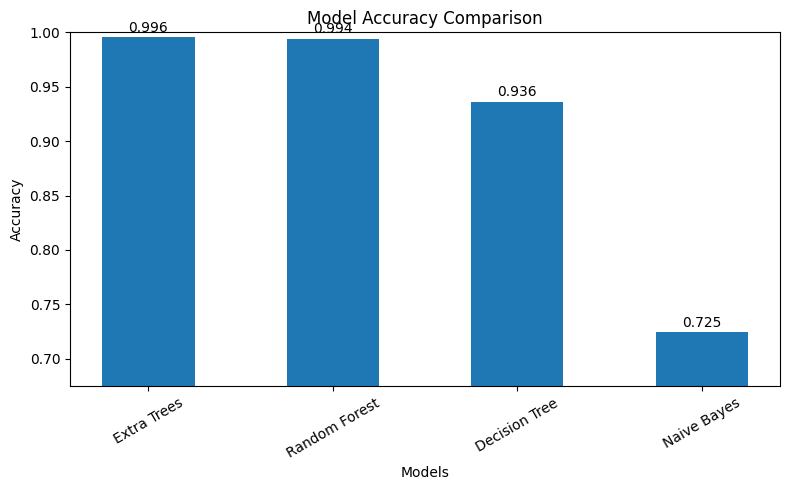

In [ ]:
import matplotlib.pyplot as plt

sorted_results = dict(sorted(results.items(), key=lambda x: x[1], reverse=True))

models = list(sorted_results.keys())
accuracies = list(sorted_results.values())

plt.figure(figsize=(8,5))

bars = plt.bar(models, accuracies, width=0.5)

for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval + 0.002,
        f"{yval:.3f}",
        ha='center',
        va='bottom'
    )

plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")

plt.ylim(min(accuracies) - 0.05, 1.0)

plt.xticks(rotation=30)
plt.tight_layout()

plt.show()

## 6.1 Confusion matrix heatmaps + full model comparison

This section visualizes where models confuse the most (top-K classes by support) and compares Accuracy + weighted F1 across all four baseline classifiers.


Baseline model comparison (Accuracy + weighted F1):


,accuracy,weighted_f1
Extra Trees,0.995986,0.995970
Random Forest,0.994266,0.994271
Decision Tree,0.936353,0.936359
Naive Bayes,0.724771,0.725580


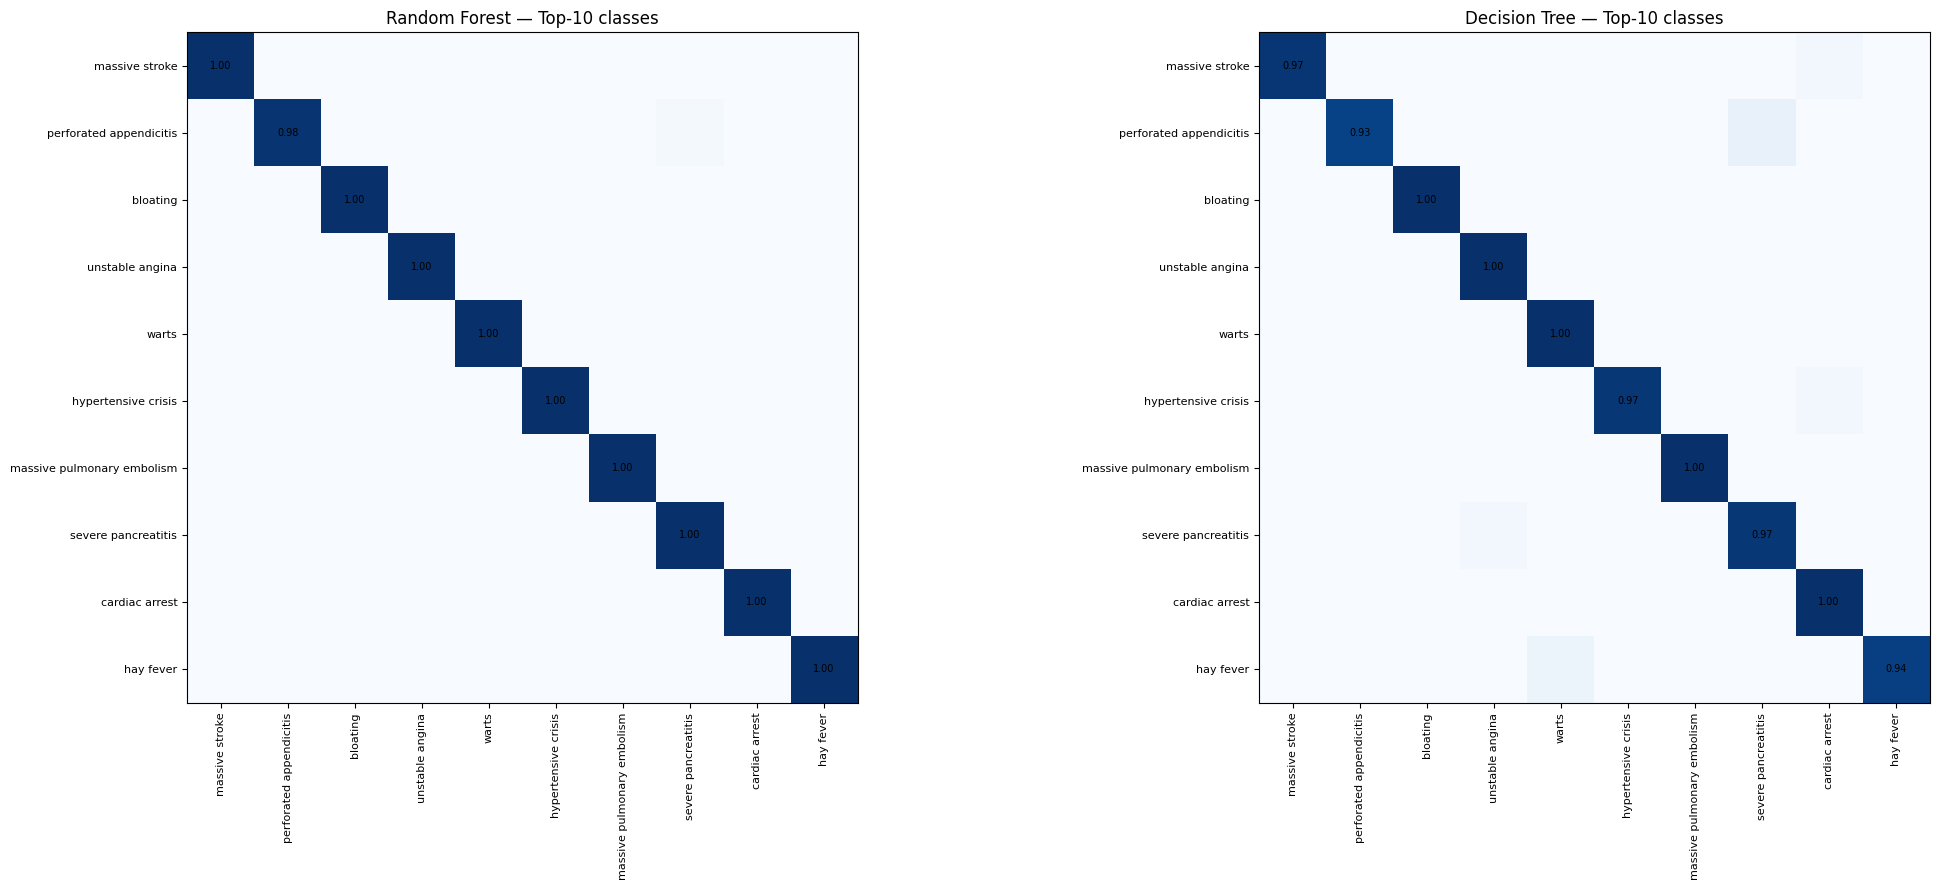


Why this helps: the heatmap shows which diseases are getting mixed up most often.
For the final system, we keep Random Forest and Decision Tree (RF for accuracy; DT for interpretability).


In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import f1_score

# ---- 1) Score table across baseline models ----
model_perf = {
    "Random Forest": {
        "accuracy": rf_acc,
        "weighted_f1": f1_score(y_test, rf_preds, average="weighted"),
    },
    "Decision Tree": {
        "accuracy": dt_acc,
        "weighted_f1": f1_score(y_test, dt_preds, average="weighted"),
    },
    "Naive Bayes": {
        "accuracy": nb_acc,
        "weighted_f1": f1_score(y_test, nb_preds, average="weighted"),
    },
    "Extra Trees": {
        "accuracy": et_acc,
        "weighted_f1": f1_score(y_test, et_preds, average="weighted"),
    },
}

perf_df = pd.DataFrame(model_perf).T.sort_values(["accuracy", "weighted_f1"], ascending=False)
print("Baseline model comparison (Accuracy + weighted F1):")
display(perf_df)

# ---- 2) Confusion matrix heatmaps (Top-K classes) ----
TOP_K = 10
support = y_test.value_counts()
top_classes = support.index[:TOP_K].tolist()
labels = [str(x) for x in top_classes]


def plot_norm_confusion(ax, y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred, labels=top_classes)
    cm = cm.astype(np.float32)
    row_sums = cm.sum(axis=1, keepdims=True)
    cm_norm = np.divide(cm, row_sums, out=np.zeros_like(cm), where=row_sums != 0)

    im = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
    ax.set_title(title)

    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=90, fontsize=8)
    ax.set_yticklabels(labels, fontsize=8)

    # Only annotate reasonably large values (keeps plot readable)
    for i in range(cm_norm.shape[0]):
        for j in range(cm_norm.shape[1]):
            v = cm_norm[i, j]
            if v >= 0.20:
                ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=7, color="black")

    return im

fig, axes = plt.subplots(1, 2, figsize=(22, 9))
plot_norm_confusion(axes[0], y_test, rf_preds, f"Random Forest — Top-{TOP_K} classes")
plot_norm_confusion(axes[1], y_test, dt_preds, f"Decision Tree — Top-{TOP_K} classes")
plt.tight_layout()
plt.show()

print("\nWhy this helps: the heatmap shows which diseases are getting mixed up most often.")
print("For the final system, we keep Random Forest and Decision Tree (RF for accuracy; DT for interpretability).")


## 7) Weighted Ensemble Voting


In [ ]:
import numpy as np

class EnsembleModel:
    def __init__(self, models, weights, voting='hard'):
        self.models = models
        self.weights = weights
        self.voting = voting

    def predict(self, X):
        if self.voting == 'soft':
            return self._soft_voting(X)
        else:
            return self._hard_voting(X)

    def _hard_voting(self, X):
        model_preds = {
            name: model.predict(X)
            for name, model in self.models.items()
        }

        final_preds = []

        for i in range(len(X)):
            votes = {}

            for name, preds in model_preds.items():
                pred = preds[i]
                weight = self.weights.get(name, 1)

                votes[pred] = votes.get(pred, 0) + weight

            final_pred = max(votes, key=votes.get)
            final_preds.append(final_pred)

        return np.array(final_preds)

    def _soft_voting(self, X):
        total_weight = sum(self.weights.values())
        weighted_probs = None

        for name, model in self.models.items():
            if not hasattr(model, "predict_proba"):
                raise ValueError(f"{name} does not support predict_proba")

            probs = model.predict_proba(X)
            weight = self.weights.get(name, 1)

            if weighted_probs is None:
                weighted_probs = weight * probs
            else:
                weighted_probs += weight * probs

        weighted_probs /= total_weight

        return np.argmax(weighted_probs, axis=1)

In [ ]:
from sklearn.metrics import accuracy_score, f1_score

models = {
    "Random Forest": rf_model,
    "Extra Trees": et_model,
    "Naive Bayes": nb_model,
    "Decision Tree": dt_model
}

weights = {
    "Random Forest": 1,
    "Extra Trees": 2,
    "Naive Bayes": 4,
    "Decision Tree": 1
}

In [ ]:
ensemble_model = EnsembleModel(models, weights)

ensemble_preds = ensemble_model.predict(X_test)

print("Ensemble Accuracy:", accuracy_score(y_test, ensemble_preds))
print("Ensemble F1 Score:", f1_score(y_test, ensemble_preds, average='weighted'))

Ensemble Accuracy: 0.9684633027522935
Ensemble F1 Score: 0.968523140641161


## 7.1 Full comparison (incl. weighted ensemble) + final selection

This compares **Accuracy** and **weighted F1** for all five systems: `RF`, `DT`, `NB`, `Extra Trees`, and the **weighted ensemble**. It also prints the final choice: **Random Forest + Decision Tree**.


Model comparison (Accuracy + weighted F1):


,accuracy,weighted_f1
Extra Trees,0.995986,0.995970
Random Forest,0.994266,0.994271
Weighted Ensemble,0.968463,0.968523
Decision Tree,0.936353,0.936359
Naive Bayes,0.724771,0.725580



Final selection:
- Random Forest: strong overall performance (used for the best triage accuracy)
- Decision Tree: keep it as a backup/interpretability model (easier to explain)


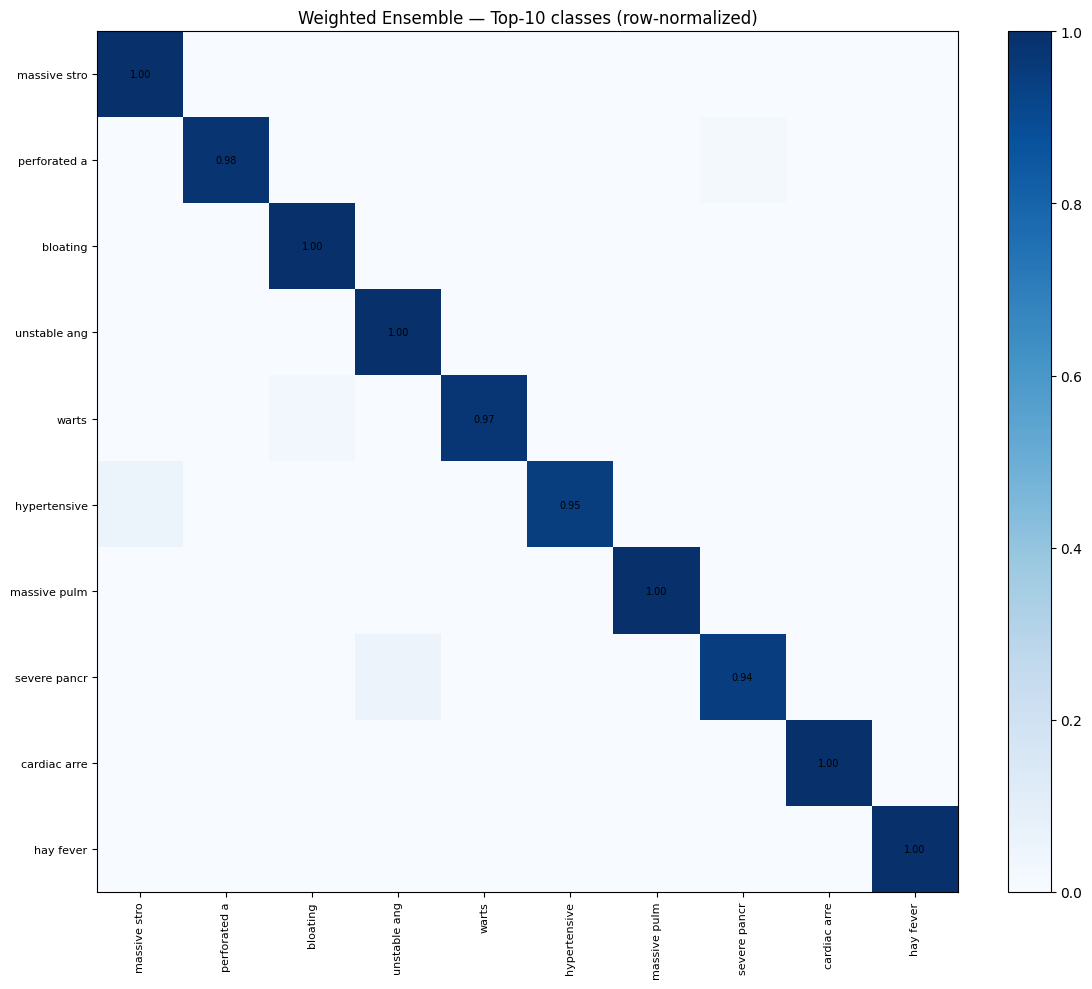

In [ ]:
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ensemble_preds already computed in the previous cell
ensemble_acc = accuracy_score(y_test, ensemble_preds)
ensemble_f1 = f1_score(y_test, ensemble_preds, average="weighted")

model_perf = {
    "Random Forest": {"accuracy": rf_acc, "weighted_f1": f1_score(y_test, rf_preds, average="weighted")},
    "Decision Tree": {"accuracy": dt_acc, "weighted_f1": f1_score(y_test, dt_preds, average="weighted")},
    "Naive Bayes": {"accuracy": nb_acc, "weighted_f1": f1_score(y_test, nb_preds, average="weighted")},
    "Extra Trees": {"accuracy": et_acc, "weighted_f1": f1_score(y_test, et_preds, average="weighted")},
    "Weighted Ensemble": {"accuracy": ensemble_acc, "weighted_f1": ensemble_f1},
}

perf_df = pd.DataFrame(model_perf).T.sort_values(["accuracy", "weighted_f1"], ascending=False)
print("\nModel comparison (Accuracy + weighted F1):")
display(perf_df)

# Final selection requested: Random Forest + Decision Tree
selected_models = ["Random Forest", "Decision Tree"]
print("\nFinal selection:")
print(f"- Random Forest: strong overall performance (used for the best triage accuracy)")
print(f"- Decision Tree: keep it as a backup/interpretability model (easier to explain)")

# ---- Heatmap for the weighted ensemble ----
TOP_K = 10
support = y_test.value_counts()
top_classes = support.index[:TOP_K].tolist()

fig, ax = plt.subplots(1, 1, figsize=(13, 10))
cm = confusion_matrix(y_test, ensemble_preds, labels=top_classes)
cm = cm.astype(np.float32)
row_sums = cm.sum(axis=1, keepdims=True)
cm_norm = np.divide(cm, row_sums, out=np.zeros_like(cm), where=row_sums != 0)

im = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
ax.set_title(f"Weighted Ensemble — Top-{TOP_K} classes (row-normalized)")
ax.set_xticks(range(len(top_classes)))
ax.set_yticks(range(len(top_classes)))
ax.set_xticklabels([str(x)[:12] for x in top_classes], rotation=90, fontsize=8)
ax.set_yticklabels([str(x)[:12] for x in top_classes], fontsize=8)

for i in range(cm_norm.shape[0]):
    for j in range(cm_norm.shape[1]):
        v = cm_norm[i, j]
        if v >= 0.20:
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=7, color="black")

plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


## 8) Symptom-Checker Demo Flow (Notebook Logic)


## 9) Export and Validate App TFLite Model


## Export `model.tflite` (used by Android & Windows apps)

The **mobile and desktop apps do not use** the sklearn disease ensemble above. They load:

| File | Purpose |
|------|---------|
| `model.tflite` | On-device neural network |
| `model_meta.json` | Output names, severity labels, input shape |
| `symptom_vocab.json` | Maps typed symptoms → model input indices |

**Model inputs:** multi-hot vector shape `(1, 234)` — one slot per symptom token (`None` at index 0).

**Model outputs (same as `test.py` and the apps):**

1. `confidence` — how sure the model is  
2. `needs_follow_up` — score ≥ 0.5 → app asks extra yes/no questions  
3. `severity` — `MILD`, `MODERATE`, or `NEEDS_REST`  
4. `suggested_symptoms` — extra symptoms to ask about (only if follow-up is needed)

**Training data:** `disease_dataset.csv` (symptom columns + `ats_level`).

Run the code cell below **once** to regenerate the three files in this folder. *(Leave unrun during a live demo if you only need to show the pipeline.)*

In [ ]:
# =============================================================================
# BUILD & EXPORT model.tflite  (SACA Android / Windows apps)
# =============================================================================
# Pipeline: disease_dataset.csv → Keras model → model.tflite + JSON sidecars
# Test after export:  python test.py

import json
from pathlib import Path

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# --- paths (same folder as this notebook) ---
APP_DIR = Path(".").resolve()
CSV_PATH = APP_DIR / "disease_dataset.csv"
VOCAB_PATH = APP_DIR / "symptom_vocab.json"
META_PATH = APP_DIR / "model_meta.json"
TFLITE_PATH = APP_DIR / "model.tflite"

SEVERITY_ORDER = ["MILD", "MODERATE", "NEEDS_REST"]
INPUT_DIM = 234          # must match model_meta.json input_shape[1]
EPOCHS = 12              # increase for better quality (e.g. 25–40)
BATCH_SIZE = 64
VAL_SPLIT = 0.15
SEED = 42

META_COLS = {"disease", "ats_level", "ats_label", "advice"}


def ats_to_severity_idx(ats_level: int) -> int:
    """Map ATS 1–5 → class index for MILD / MODERATE / NEEDS_REST."""
    if ats_level <= 2:
        return 1   # MODERATE (emergency / hospital)
    if ats_level == 3:
        return 1   # MODERATE (urgent)
    if ats_level == 4:
        return 0   # MILD (GP)
    return 2       # NEEDS_REST (self-care)


def load_training_data():
    df = pd.read_csv(CSV_PATH)
    df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

    if VOCAB_PATH.exists():
        vocab = json.loads(VOCAB_PATH.read_text(encoding="utf-8"))
    else:
        symptom_cols = [c for c in df.columns if c not in META_COLS]
        vocab = ["None"] + symptom_cols

    token_to_idx = {t: i for i, t in enumerate(vocab) if i < INPUT_DIM}

    symptom_cols = [c for c in df.columns if c not in META_COLS]
    X = np.zeros((len(df), INPUT_DIM), dtype=np.float32)
    for col in symptom_cols:
        idx = token_to_idx.get(col)
        if idx is None:
            continue
        X[:, idx] = pd.to_numeric(df[col], errors="coerce").fillna(0).values.astype(np.float32)

    # labels derived from ATS + symptom count (matches app triage idea)
    ats = df["ats_level"].astype(int).values
    active = X.sum(axis=1)

    y_severity = np.array([ats_to_severity_idx(a) for a in ats], dtype=np.int32)
    y_confidence = np.clip(0.92 - 0.08 * (ats - 1), 0.45, 0.95).astype(np.float32)
    y_followup = ((active < 3) | (ats <= 3)).astype(np.float32)

    # suggestion target: symptoms often seen in the dataset but not on this row
    y_suggest = np.zeros((len(df), INPUT_DIM), dtype=np.float32)
    for j in range(INPUT_DIM):
        if j >= len(vocab) or vocab[j].lower() == "none":
            continue
        col_rate = X[:, j].mean()
        y_suggest[:, j] = np.clip(col_rate * (1 - X[:, j]), 0, 1).astype(np.float32)

    return X, y_confidence, y_followup, y_severity, y_suggest, vocab


def build_model():
    inputs = keras.Input(shape=(INPUT_DIM,), name="symptoms")

    x = layers.Dense(128, activation="relu")(inputs)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(64, activation="relu")(x)

    out_confidence = layers.Dense(1, activation="sigmoid", name="confidence")(x)
    out_followup = layers.Dense(1, activation="sigmoid", name="needs_follow_up")(x)
    out_severity = layers.Dense(len(SEVERITY_ORDER), activation="softmax", name="severity")(x)
    out_suggest = layers.Dense(INPUT_DIM, activation="sigmoid", name="suggested_symptoms")(x)

    model = keras.Model(
        inputs=inputs,
        outputs=[out_confidence, out_followup, out_severity, out_suggest],
    )
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss={
            "confidence": "mse",
            "needs_follow_up": "binary_crossentropy",
            "severity": "sparse_categorical_crossentropy",
            "suggested_symptoms": "binary_crossentropy",
        },
        loss_weights={
            "confidence": 1.0,
            "needs_follow_up": 1.0,
            "severity": 2.0,
            "suggested_symptoms": 0.5,
        },
        metrics={
            "severity": "accuracy",
            "needs_follow_up": "accuracy",
        },
    )
    return model


def export_tflite(keras_model):
    converter = tf.lite.TFLiteConverter.from_keras_model(keras_model)
    converter.target_spec.supported_ops = [
        tf.lite.OpsSet.TFLITE_BUILTINS,
        tf.lite.OpsSet.SELECT_TF_OPS,
    ]
    converter._experimental_lower_tensor_list_ops = False
    tflite_model = converter.convert()
    TFLITE_PATH.write_bytes(tflite_model)
    print(f"Saved {TFLITE_PATH} ({len(tflite_model) / 1024:.1f} KB)")


def save_sidecars(vocab):
    VOCAB_PATH.write_text(json.dumps(vocab, indent=2), encoding="utf-8")
    meta = {
        "output_order": [
            "confidence",
            "needs_follow_up",
            "severity",
            "suggested_symptoms",
        ],
        "severity_order": SEVERITY_ORDER,
        "input_shape": [1, INPUT_DIM],
        "vocab_first_token": "None",
        "note": "Show suggested_symptoms only when needs_follow_up >= 0.5",
    }
    META_PATH.write_text(json.dumps(meta, indent=2), encoding="utf-8")
    print(f"Saved {VOCAB_PATH.name}, {META_PATH.name}")


# --- run export (set True when you actually want to retrain) ---
RUN_EXPORT = False
# RUN_EXPORT = True

if RUN_EXPORT:
    np.random.seed(SEED)
    tf.random.set_seed(SEED)

    X, y_conf, y_follow, y_sev, y_sug, vocab = load_training_data()
    print(f"Training samples: {X.shape[0]:,}  |  input dim: {INPUT_DIM}  |  vocab tokens: {len(vocab)}")

    model = build_model()
    model.summary()

    history = model.fit(
        X,
        {
            "confidence": y_conf,
            "needs_follow_up": y_follow,
            "severity": y_sev,
            "suggested_symptoms": y_sug,
        },
        validation_split=VAL_SPLIT,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        verbose=1,
    )

    export_tflite(model)
    save_sidecars(vocab)

    print("\nDone. Copy these three files into:")
    print("  - saca-android-app/app/src/main/assets/")
    print("  - saca-windows-app-v3/models/ml/")
    print("Then run:  python test.py")
else:
    print("Export cell ready — set RUN_EXPORT = True to train and write model.tflite")


Export cell ready — set RUN_EXPORT = True to train and write model.tflite


## 10) Colab TFLite Two-Step Scenario Tests (10 Cases)


In [ ]:
# =============================================================================
# Colab TFLite inference (mirrors test.py + apps)
# =============================================================================

# !pip install -q tensorflow

import json
import re
from pathlib import Path
from difflib import get_close_matches

import numpy as np

MODEL_DIR = Path("/content/drive/MyDrive/Dataset/")


FOLLOW_UP_THRESHOLD = 0.5

SYMPTOM_PHRASE_MAP = {
    "none": "None",
    "fever": "fever",
    "mild fever": "mild_fever",
    "high fever": "high_fever",
    "chills": "chills",
    "cough": "cough",
    "mild cough": "mild_cough",
    "productive cough": "productive_cough",
    "runny nose": "runny_nose",
    "nasal congestion": "nasal_congestion",
    "sore throat": "sore_throat",
    "fatigue": "fatigue",
    "body aches": "body_aches",
    "headache": "headache",
    "mild headache": "mild_headache",
    "severe headache": "severe_headache",
    "nausea": "nausea",
    "vomiting": "vomiting",
    "vomit": "vomiting",
    "diarrhea": "diarrhea",
    "diarrhoea": "diarrhea",
    "abdominal pain": "abdominal_pain",
    "stomach pain": "abdominal_pain",
    "severe abdominal pain": "severe_abdominal_pain",
    "chest pain": "chest_pain",
    "crushing chest pain": "crushing_chest_pain",
    "severe chest pain": "severe_chest_pain",
    "shortness of breath": "shortness_of_breath",
    "difficulty breathing": "difficulty_breathing",
    "severe difficulty breathing": "severe_difficulty_breathing",
    "wheezing": "wheezing",
    "not breathing": "not_breathing",
    "dizziness": "dizziness",
    "sweating": "sweating",
    "confusion": "confusion",
    "collapse": "collapse",
    "cyanosis": "cyanosis",
}


def _load_json(p):
    return json.loads(Path(p).read_text(encoding="utf-8"))


def _pick_interpreter():
    for mod in (
        "tflite_runtime.interpreter",
        "tensorflow.lite.python.interpreter",
        "tensorflow.lite",
    ):
        try:
            Interpreter = __import__(mod, fromlist=["Interpreter"]).Interpreter
            return Interpreter
        except Exception:
            continue
    raise RuntimeError("Install TensorFlow or tflite-runtime")


class TFLiteRunner:
    def __init__(self, model_dir):
        self.model_dir = Path(model_dir)
        self.meta = _load_json(self.model_dir / "model_meta.json")
        self.vocab = _load_json(self.model_dir / "symptom_vocab.json")
        self.index = {t: i for i, t in enumerate(self.vocab)}
        self.input_size = int((self.meta.get("input_shape") or [1, len(self.vocab)])[1])
        self.output_order = list(self.meta.get("output_order") or [])
        self.severity_order = list(self.meta.get("severity_order") or ["MILD", "MODERATE", "NEEDS_REST"])

        Interpreter = _pick_interpreter()
        self.interpreter = Interpreter(model_path=str(self.model_dir / "model.tflite"))
        self.interpreter.allocate_tensors()
        self.input_details = self.interpreter.get_input_details()
        self.output_details = self.interpreter.get_output_details()

    def normalize(self, phrase):
        key = (phrase or "").strip().lower().replace("-", " ").replace("_", " ")
        key = re.sub(r"\s+", " ", key).strip()
        if key in SYMPTOM_PHRASE_MAP:
            return SYMPTOM_PHRASE_MAP[key]
        unders = key.replace(" ", "_")
        if unders in self.index:
            return unders
        cand = [v for v in self.vocab if v.lower() != "none"]
        hit = get_close_matches(unders, cand, n=1, cutoff=0.86)
        return hit[0] if hit else unders

    def phrases_to_tokens(self, phrases):
        out = []
        for p in phrases:
            t = self.normalize(p)
            if t and t in self.index and t.lower() != "none" and t not in out:
                out.append(t)
        return out

    def vector(self, tokens):
        v = np.zeros((1, self.input_size), dtype=np.float32)
        if not tokens and "None" in self.index:
            v[0, self.index["None"]] = 1.0
            return v
        for t in tokens:
            j = self.index.get(t)
            if j is not None and j < self.input_size:
                v[0, j] = 1.0
        return v

    def _scalar(self, x, default):
        a = np.array(x, dtype=float).reshape(-1)
        if a.size == 0:
            return default
        return float(a[0] if a.size == 1 else a.max())

    def _severity(self, x):
        try:
            a = np.array(x).reshape(-1)
            idx = int(round(float(a[0]))) if a.size == 1 else int(np.argmax(a))
            if 0 <= idx < len(self.severity_order):
                return self.severity_order[idx].upper()
        except Exception:
            pass
        return "MILD"

    def suggestions(self, x, top_n=4):
        if x is None:
            return []
        arr = np.array(x).reshape(-1)
        out = []
        if arr.size == len(self.vocab):
            for idx in np.argsort(arr.astype(float))[::-1]:
                sym = self.vocab[int(idx)]
                sc = float(arr[int(idx)])
                if sym.lower() == "none" or sc <= 0.05:
                    if sc <= 0.05:
                        break
                    continue
                if sym not in out:
                    out.append(sym)
                if len(out) >= top_n:
                    break
            return out
        for raw in arr[:20]:
            idx = int(round(float(raw)))
            if 0 <= idx < len(self.vocab):
                sym = self.vocab[idx]
                if sym.lower() != "none" and sym not in out:
                    out.append(sym)
            if len(out) >= top_n:
                break
        return out

    def predict_from_phrases(self, phrases):
        tokens = self.phrases_to_tokens(phrases)
        vec = self.vector(tokens)
        self.interpreter.set_tensor(self.input_details[0]["index"], vec)
        self.interpreter.invoke()
        outs = [self.interpreter.get_tensor(d["index"]) for d in self.output_details]
        bag = {self.output_order[i]: outs[i] for i in range(min(len(self.output_order), len(outs)))}
        conf = self._scalar(bag.get("confidence"), 0.55)
        nfs = self._scalar(bag.get("needs_follow_up"), 0.0)
        sev = self._severity(bag.get("severity"))
        sug = self.suggestions(bag.get("suggested_symptoms"))
        need = nfs >= FOLLOW_UP_THRESHOLD
        if not need:
            sug = []
        return {
            "mapped_tokens": tokens,
            "confidence": conf,
            "needs_follow_up_score": nfs,
            "needs_follow_up": need,
            "severity": sev,
            "suggested_symptoms": sug,
        }


def _fmt(s):
    return str(s).replace("_", " ")


def print_round(label, phrases, r):
    print(f"\n=== {label} ===")
    print("Input phrases:", phrases)
    print("Mapped tokens:", r["mapped_tokens"] or ["(None only)"])
    print(f"  confidence:      {r['confidence']:.3f}")
    print(f"  needs_follow_up: {r['needs_follow_up_score']:.3f} → {r['needs_follow_up']} (threshold {FOLLOW_UP_THRESHOLD})")
    print(f"  severity:        {r['severity']}")
    if r["needs_follow_up"] and r["suggested_symptoms"]:
        print("  model suggested_symptoms:", ", ".join(_fmt(x) for x in r["suggested_symptoms"]))
    elif r["needs_follow_up"]:
        print("  model suggested_symptoms: (none above cutoff)")
    else:
        print("  model suggested_symptoms: (cleared — follow-up score below threshold)")


def run_two_step_demo(title, initial_phrases, followup_yes_phrases, explain=""):
    """First pass = user input. Second pass = same input + symptoms they answered YES to."""
    print("\n" + "#" * 72)
    print(f"# {title}")
    if explain:
        print(f"# {explain}")
    print("#" * 72)
    r1 = RUNNER.predict_from_phrases(initial_phrases)
    print_round("Round 1 — initial input (like first app screen)", initial_phrases, r1)
    if not followup_yes_phrases:
        print("\n(No second round — no extra symptoms added.)")
        return r1, None
    merged = list(initial_phrases) + list(followup_yes_phrases)
    print("\n--- Simulating follow-up: user answered YES to adding ---")
    print("   ", ", ".join(followup_yes_phrases))
    r2 = RUNNER.predict_from_phrases(merged)
    print_round("Round 2 — after yes to follow-up symptoms (like final assessment)", merged, r2)
    return r1, r2


# Create runner (re-run this cell if you change MODEL_DIR)
for _name in ("model.tflite", "model_meta.json", "symptom_vocab.json"):
    _p = MODEL_DIR / _name
    if not _p.is_file():
        raise FileNotFoundError(
            f"Missing {_p} — upload the three ML files or fix MODEL_DIR path."
        )
RUNNER = TFLiteRunner(MODEL_DIR)
print("TFLite OK —", MODEL_DIR.resolve())


TFLite OK — /content/drive/MyDrive/Dataset


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [ ]:
# Scenario 1 — Mild cold; follow-up: add fatigue
# Sparse cold picture first; second round adds tiredness the user confirms.
run_two_step_demo(
    """Scenario 1 — Mild cold; follow-up: add fatigue""",
    "mild fever, cough, runny nose, sore throat".split(", "),
    ['fatigue'],
    """Sparse cold picture first; second round adds tiredness the user confirms.""",
)




########################################################################
# Scenario 1 — Mild cold; follow-up: add fatigue
# Sparse cold picture first; second round adds tiredness the user confirms.
########################################################################

=== Round 1 — initial input (like first app screen) ===
Input phrases: ['mild fever', 'cough', 'runny nose', 'sore throat']
Mapped tokens: ['mild_fever', 'cough', 'runny_nose', 'sore_throat']
  confidence:      0.765
  needs_follow_up: 0.810 → True (threshold 0.5)
  severity:        MILD
  model suggested_symptoms: skin warmth, bruising, eye discharge, rash

--- Simulating follow-up: user answered YES to adding ---
    fatigue

=== Round 2 — after yes to follow-up symptoms (like final assessment) ===
Input phrases: ['mild fever', 'cough', 'runny nose', 'sore throat', 'fatigue']
Mapped tokens: ['mild_fever', 'cough', 'runny_nose', 'sore_throat', 'fatigue']
  confidence:      0.782
  needs_follow_up: 0.860 → True (thres

({'mapped_tokens': ['mild_fever', 'cough', 'runny_nose', 'sore_throat'],
  'confidence': 0.7646329402923584,
  'needs_follow_up_score': 0.8100505471229553,
  'needs_follow_up': True,
  'severity': 'MILD',
  'suggested_symptoms': ['skin_warmth', 'bruising', 'eye_discharge', 'rash']},
 {'mapped_tokens': ['mild_fever',
   'cough',
   'runny_nose',
   'sore_throat',
   'fatigue'],
  'confidence': 0.7819151878356934,
  'needs_follow_up_score': 0.8604851365089417,
  'needs_follow_up': True,
  'severity': 'MILD',
  'suggested_symptoms': ['skin_warmth',
   'bruising',
   'nystagmus',
   'pain_after_fatty_food']})

In [ ]:
# Scenario 2 — Sparse fever + cough; follow-up: high fever + difficulty breathing
# Mimics app asking for red-flag respiratory symptoms after a thin first input.
run_two_step_demo(
    """Scenario 2 — Sparse fever + cough; follow-up: high fever + difficulty breathing""",
    "fever, cough".split(", "),
    ['high fever', 'difficulty breathing'],
    """Mimics app asking for red-flag respiratory symptoms after a thin first input.""",
)




########################################################################
# Scenario 2 — Sparse fever + cough; follow-up: high fever + difficulty breathing
# Mimics app asking for red-flag respiratory symptoms after a thin first input.
########################################################################

=== Round 1 — initial input (like first app screen) ===
Input phrases: ['fever', 'cough']
Mapped tokens: ['fever', 'cough']
  confidence:      0.689
  needs_follow_up: 0.702 → True (threshold 0.5)
  severity:        MILD
  model suggested_symptoms: skin warmth, bruising, eye discharge, rash

--- Simulating follow-up: user answered YES to adding ---
    high fever, difficulty breathing

=== Round 2 — after yes to follow-up symptoms (like final assessment) ===
Input phrases: ['fever', 'cough', 'high fever', 'difficulty breathing']
Mapped tokens: ['fever', 'cough', 'high_fever', 'difficulty_breathing']
  confidence:      0.739
  needs_follow_up: 0.769 → True (threshold 0.5)
  severity

({'mapped_tokens': ['fever', 'cough'],
  'confidence': 0.6894353628158569,
  'needs_follow_up_score': 0.7019659876823425,
  'needs_follow_up': True,
  'severity': 'MILD',
  'suggested_symptoms': ['skin_warmth', 'bruising', 'eye_discharge', 'rash']},
 {'mapped_tokens': ['fever', 'cough', 'high_fever', 'difficulty_breathing'],
  'confidence': 0.7392075657844543,
  'needs_follow_up_score': 0.7687207460403442,
  'needs_follow_up': True,
  'severity': 'MILD',
  'suggested_symptoms': ['skin_warmth', 'bruising', 'nystagmus', 'rash']})

In [ ]:
# Scenario 3 — GI bug; follow-up: severe abdominal pain
# User reports worse belly pain on follow-up.
run_two_step_demo(
    """Scenario 3 — GI bug; follow-up: severe abdominal pain""",
    "abdominal pain, vomiting, diarrhea, nausea".split(", "),
    ['severe abdominal pain'],
    """User reports worse belly pain on follow-up.""",
)




########################################################################
# Scenario 3 — GI bug; follow-up: severe abdominal pain
# User reports worse belly pain on follow-up.
########################################################################

=== Round 1 — initial input (like first app screen) ===
Input phrases: ['abdominal pain', 'vomiting', 'diarrhea', 'nausea']
Mapped tokens: ['abdominal_pain', 'vomiting', 'diarrhea', 'nausea']
  confidence:      0.724
  needs_follow_up: 0.786 → True (threshold 0.5)
  severity:        MILD
  model suggested_symptoms: skin warmth, bruising, nystagmus, pain after fatty food

--- Simulating follow-up: user answered YES to adding ---
    severe abdominal pain

=== Round 2 — after yes to follow-up symptoms (like final assessment) ===
Input phrases: ['abdominal pain', 'vomiting', 'diarrhea', 'nausea', 'severe abdominal pain']
Mapped tokens: ['abdominal_pain', 'vomiting', 'diarrhea', 'nausea', 'severe_abdominal_pain']
  confidence:      0.771
  need

({'mapped_tokens': ['abdominal_pain', 'vomiting', 'diarrhea', 'nausea'],
  'confidence': 0.7240424156188965,
  'needs_follow_up_score': 0.7864317297935486,
  'needs_follow_up': True,
  'severity': 'MILD',
  'suggested_symptoms': ['skin_warmth',
   'bruising',
   'nystagmus',
   'pain_after_fatty_food']},
 {'mapped_tokens': ['abdominal_pain',
   'vomiting',
   'diarrhea',
   'nausea',
   'severe_abdominal_pain'],
  'confidence': 0.7709017992019653,
  'needs_follow_up_score': 0.841844379901886,
  'needs_follow_up': True,
  'severity': 'MILD',
  'suggested_symptoms': ['skin_warmth',
   'nosebleed',
   'nystagmus',
   'pain_after_fatty_food']})

In [ ]:
# Scenario 4 — Chest pressure; follow-up: dizziness
# Already serious cluster; second pass adds neuro symptom user confirms.
run_two_step_demo(
    """Scenario 4 — Chest pressure; follow-up: dizziness""",
    "crushing chest pain, shortness of breath, sweating, nausea".split(", "),
    ['dizziness'],
    """Already serious cluster; second pass adds neuro symptom user confirms.""",
)




########################################################################
# Scenario 4 — Chest pressure; follow-up: dizziness
# Already serious cluster; second pass adds neuro symptom user confirms.
########################################################################

=== Round 1 — initial input (like first app screen) ===
Input phrases: ['crushing chest pain', 'shortness of breath', 'sweating', 'nausea']
Mapped tokens: ['crushing_chest_pain', 'shortness_of_breath', 'sweating', 'nausea']
  confidence:      0.744
  needs_follow_up: 0.774 → True (threshold 0.5)
  severity:        MILD
  model suggested_symptoms: sneezing, bruising, eye discharge, pain after fatty food

--- Simulating follow-up: user answered YES to adding ---
    dizziness

=== Round 2 — after yes to follow-up symptoms (like final assessment) ===
Input phrases: ['crushing chest pain', 'shortness of breath', 'sweating', 'nausea', 'dizziness']
Mapped tokens: ['crushing_chest_pain', 'shortness_of_breath', 'sweating', 'n

({'mapped_tokens': ['crushing_chest_pain',
   'shortness_of_breath',
   'sweating',
   'nausea'],
  'confidence': 0.7441258430480957,
  'needs_follow_up_score': 0.7744046449661255,
  'needs_follow_up': True,
  'severity': 'MILD',
  'suggested_symptoms': ['sneezing',
   'bruising',
   'eye_discharge',
   'pain_after_fatty_food']},
 {'mapped_tokens': ['crushing_chest_pain',
   'shortness_of_breath',
   'sweating',
   'nausea',
   'dizziness'],
  'confidence': 0.7673470973968506,
  'needs_follow_up_score': 0.8091775178909302,
  'needs_follow_up': True,
  'severity': 'MILD',
  'suggested_symptoms': ['skin_warmth',
   'bruising',
   'eye_discharge',
   'pain_after_fatty_food']})

In [ ]:
# Scenario 5 — Cough + breath + chest; follow-up: wheezing
# Airway narrowing added on follow-up.
run_two_step_demo(
    """Scenario 5 — Cough + breath + chest; follow-up: wheezing""",
    "cough, difficulty breathing, chest pain, fatigue".split(", "),
    ['wheezing'],
    """Airway narrowing added on follow-up.""",
)




########################################################################
# Scenario 5 — Cough + breath + chest; follow-up: wheezing
# Airway narrowing added on follow-up.
########################################################################

=== Round 1 — initial input (like first app screen) ===
Input phrases: ['cough', 'difficulty breathing', 'chest pain', 'fatigue']
Mapped tokens: ['cough', 'difficulty_breathing', 'chest_pain', 'fatigue']
  confidence:      0.768
  needs_follow_up: 0.845 → True (threshold 0.5)
  severity:        MILD
  model suggested_symptoms: skin warmth, bruising, nystagmus, pain after fatty food

--- Simulating follow-up: user answered YES to adding ---
    wheezing

=== Round 2 — after yes to follow-up symptoms (like final assessment) ===
Input phrases: ['cough', 'difficulty breathing', 'chest pain', 'fatigue', 'wheezing']
Mapped tokens: ['cough', 'difficulty_breathing', 'chest_pain', 'fatigue', 'wheezing']
  confidence:      0.811
  needs_follow_up: 0.895 

({'mapped_tokens': ['cough', 'difficulty_breathing', 'chest_pain', 'fatigue'],
  'confidence': 0.7680234313011169,
  'needs_follow_up_score': 0.84520423412323,
  'needs_follow_up': True,
  'severity': 'MILD',
  'suggested_symptoms': ['skin_warmth',
   'bruising',
   'nystagmus',
   'pain_after_fatty_food']},
 {'mapped_tokens': ['cough',
   'difficulty_breathing',
   'chest_pain',
   'fatigue',
   'wheezing'],
  'confidence': 0.8110480308532715,
  'needs_follow_up_score': 0.8951951861381531,
  'needs_follow_up': True,
  'severity': 'MILD',
  'suggested_symptoms': ['skin_warmth',
   'bruising',
   'nystagmus',
   'pain_after_fatty_food']})

In [ ]:
# Scenario 6 — Flu-like; follow-up: chills
# Classic flu picture; user confirms chills.
run_two_step_demo(
    """Scenario 6 — Flu-like; follow-up: chills""",
    "fever, cough, body aches, fatigue".split(", "),
    ['chills'],
    """Classic flu picture; user confirms chills.""",
)




########################################################################
# Scenario 6 — Flu-like; follow-up: chills
# Classic flu picture; user confirms chills.
########################################################################

=== Round 1 — initial input (like first app screen) ===
Input phrases: ['fever', 'cough', 'body aches', 'fatigue']
Mapped tokens: ['fever', 'cough', 'body_aches', 'fatigue']
  confidence:      0.780
  needs_follow_up: 0.856 → True (threshold 0.5)
  severity:        MILD
  model suggested_symptoms: skin warmth, bruising, nystagmus, pain after fatty food

--- Simulating follow-up: user answered YES to adding ---
    chills

=== Round 2 — after yes to follow-up symptoms (like final assessment) ===
Input phrases: ['fever', 'cough', 'body aches', 'fatigue', 'chills']
Mapped tokens: ['fever', 'cough', 'body_aches', 'fatigue', 'chills']
  confidence:      0.816
  needs_follow_up: 0.887 → True (threshold 0.5)
  severity:        MILD
  model suggested_symptoms: s

({'mapped_tokens': ['fever', 'cough', 'body_aches', 'fatigue'],
  'confidence': 0.7804617285728455,
  'needs_follow_up_score': 0.8560954332351685,
  'needs_follow_up': True,
  'severity': 'MILD',
  'suggested_symptoms': ['skin_warmth',
   'bruising',
   'nystagmus',
   'pain_after_fatty_food']},
 {'mapped_tokens': ['fever', 'cough', 'body_aches', 'fatigue', 'chills'],
  'confidence': 0.8157957196235657,
  'needs_follow_up_score': 0.8873864412307739,
  'needs_follow_up': True,
  'severity': 'MILD',
  'suggested_symptoms': ['skin_warmth',
   'bruising',
   'nystagmus',
   'pain_after_fatty_food']})

In [ ]:
# Scenario 7 — Headache cluster; follow-up: severe headache + vomiting
# Worsening headache and vomiting on follow-up.
run_two_step_demo(
    """Scenario 7 — Headache cluster; follow-up: severe headache + vomiting""",
    "headache, dizziness, nausea".split(", "),
    ['severe headache', 'vomiting'],
    """Worsening headache and vomiting on follow-up.""",
)




########################################################################
# Scenario 7 — Headache cluster; follow-up: severe headache + vomiting
# Worsening headache and vomiting on follow-up.
########################################################################

=== Round 1 — initial input (like first app screen) ===
Input phrases: ['headache', 'dizziness', 'nausea']
Mapped tokens: ['headache', 'dizziness', 'nausea']
  confidence:      0.714
  needs_follow_up: 0.688 → True (threshold 0.5)
  severity:        MILD
  model suggested_symptoms: tingling, bruising, eye discharge, pain after fatty food

--- Simulating follow-up: user answered YES to adding ---
    severe headache, vomiting

=== Round 2 — after yes to follow-up symptoms (like final assessment) ===
Input phrases: ['headache', 'dizziness', 'nausea', 'severe headache', 'vomiting']
Mapped tokens: ['headache', 'dizziness', 'nausea', 'severe_headache', 'vomiting']
  confidence:      0.741
  needs_follow_up: 0.756 → True (thresho

({'mapped_tokens': ['headache', 'dizziness', 'nausea'],
  'confidence': 0.7141393423080444,
  'needs_follow_up_score': 0.6882783770561218,
  'needs_follow_up': True,
  'severity': 'MILD',
  'suggested_symptoms': ['tingling',
   'bruising',
   'eye_discharge',
   'pain_after_fatty_food']},
 {'mapped_tokens': ['headache',
   'dizziness',
   'nausea',
   'severe_headache',
   'vomiting'],
  'confidence': 0.7405757904052734,
  'needs_follow_up_score': 0.7562376856803894,
  'needs_follow_up': True,
  'severity': 'MILD',
  'suggested_symptoms': ['skin_warmth',
   'bruising',
   'eye_discharge',
   'pain_after_fatty_food']})

In [ ]:
# Scenario 8 — Minimal ENT; follow-up: fever + productive cough
# Starts mild; user confirms infection-type symptoms.
run_two_step_demo(
    """Scenario 8 — Minimal ENT; follow-up: fever + productive cough""",
    "sore throat, mild cough".split(", "),
    ['fever', 'productive cough'],
    """Starts mild; user confirms infection-type symptoms.""",
)




########################################################################
# Scenario 8 — Minimal ENT; follow-up: fever + productive cough
# Starts mild; user confirms infection-type symptoms.
########################################################################

=== Round 1 — initial input (like first app screen) ===
Input phrases: ['sore throat', 'mild cough']
Mapped tokens: ['sore_throat', 'mild_cough']
  confidence:      0.692
  needs_follow_up: 0.674 → True (threshold 0.5)
  severity:        MILD
  model suggested_symptoms: tingling, bruising, eye discharge, pain after fatty food

--- Simulating follow-up: user answered YES to adding ---
    fever, productive cough

=== Round 2 — after yes to follow-up symptoms (like final assessment) ===
Input phrases: ['sore throat', 'mild cough', 'fever', 'productive cough']
Mapped tokens: ['sore_throat', 'mild_cough', 'fever', 'productive_cough']
  confidence:      0.807
  needs_follow_up: 0.846 → True (threshold 0.5)
  severity:        MODE

({'mapped_tokens': ['sore_throat', 'mild_cough'],
  'confidence': 0.691908597946167,
  'needs_follow_up_score': 0.6739588379859924,
  'needs_follow_up': True,
  'severity': 'MILD',
  'suggested_symptoms': ['tingling',
   'bruising',
   'eye_discharge',
   'pain_after_fatty_food']},
 {'mapped_tokens': ['sore_throat', 'mild_cough', 'fever', 'productive_cough'],
  'confidence': 0.8071796894073486,
  'needs_follow_up_score': 0.8456777334213257,
  'needs_follow_up': True,
  'severity': 'MODERATE',
  'suggested_symptoms': ['skin_warmth',
   'no_pulse',
   'nystagmus',
   'pain_after_fatty_food']})

In [ ]:
# Scenario 9 — Chest + cough only; follow-up: severe chest pain
# Escalation from generic chest + cough to severe pain.
run_two_step_demo(
    """Scenario 9 — Chest + cough only; follow-up: severe chest pain""",
    "chest pain, cough".split(", "),
    ['severe chest pain'],
    """Escalation from generic chest + cough to severe pain.""",
)




########################################################################
# Scenario 9 — Chest + cough only; follow-up: severe chest pain
# Escalation from generic chest + cough to severe pain.
########################################################################

=== Round 1 — initial input (like first app screen) ===
Input phrases: ['chest pain', 'cough']
Mapped tokens: ['chest_pain', 'cough']
  confidence:      0.693
  needs_follow_up: 0.680 → True (threshold 0.5)
  severity:        MILD
  model suggested_symptoms: skin warmth, bruising, nystagmus, pain after fatty food

--- Simulating follow-up: user answered YES to adding ---
    severe chest pain

=== Round 2 — after yes to follow-up symptoms (like final assessment) ===
Input phrases: ['chest pain', 'cough', 'severe chest pain']
Mapped tokens: ['chest_pain', 'cough', 'severe_chest_pain']
  confidence:      0.715
  needs_follow_up: 0.758 → True (threshold 0.5)
  severity:        MILD
  model suggested_symptoms: skin warmth, no 

({'mapped_tokens': ['chest_pain', 'cough'],
  'confidence': 0.6927923560142517,
  'needs_follow_up_score': 0.6796326637268066,
  'needs_follow_up': True,
  'severity': 'MILD',
  'suggested_symptoms': ['skin_warmth',
   'bruising',
   'nystagmus',
   'pain_after_fatty_food']},
 {'mapped_tokens': ['chest_pain', 'cough', 'severe_chest_pain'],
  'confidence': 0.7150195837020874,
  'needs_follow_up_score': 0.7581828236579895,
  'needs_follow_up': True,
  'severity': 'MILD',
  'suggested_symptoms': ['skin_warmth', 'no_pulse', 'nystagmus', 'rash']})

In [ ]:
# Scenario 10 — Single symptom; follow-up: confusion
# One strong finding; follow-up adds altered mental status.
run_two_step_demo(
    """Scenario 10 — Single symptom; follow-up: confusion""",
    "high fever".split(", "),
    ['confusion'],
    """One strong finding; follow-up adds altered mental status.""",
)




########################################################################
# Scenario 10 — Single symptom; follow-up: confusion
# One strong finding; follow-up adds altered mental status.
########################################################################

=== Round 1 — initial input (like first app screen) ===
Input phrases: ['high fever']
Mapped tokens: ['high_fever']
  confidence:      0.622
  needs_follow_up: 0.552 → True (threshold 0.5)
  severity:        MILD
  model suggested_symptoms: tingling, anal pain, nystagmus, pain after fatty food

--- Simulating follow-up: user answered YES to adding ---
    confusion

=== Round 2 — after yes to follow-up symptoms (like final assessment) ===
Input phrases: ['high fever', 'confusion']
Mapped tokens: ['high_fever', 'confusion']
  confidence:      0.674
  needs_follow_up: 0.689 → True (threshold 0.5)
  severity:        MILD
  model suggested_symptoms: skin warmth, bruising, warmth, pain after fatty food


({'mapped_tokens': ['high_fever'],
  'confidence': 0.6224128007888794,
  'needs_follow_up_score': 0.5522905588150024,
  'needs_follow_up': True,
  'severity': 'MILD',
  'suggested_symptoms': ['tingling',
   'anal_pain',
   'nystagmus',
   'pain_after_fatty_food']},
 {'mapped_tokens': ['high_fever', 'confusion'],
  'confidence': 0.6736751794815063,
  'needs_follow_up_score': 0.6888381838798523,
  'needs_follow_up': True,
  'severity': 'MILD',
  'suggested_symptoms': ['skin_warmth',
   'bruising',
   'warmth',
   'pain_after_fatty_food']})